# Task 1 — Trend-Following Strategy

**BUSI97075-2526 | Applied Trading Strategies**

In [ ]:
%load_ext autoreload
%autoreload 2

import sys, os, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

from functools import partial

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid']  = True
plt.rcParams['grid.alpha'] = 0.25

from strategy              import build_signals, run_strategy
from signals.signal_layer1 import layer1_signal
from signals.signal_exit   import long_exit_signal, short_exit_signal
from analytics             import performance_stats, sector_contribution, position_summary, plot_signals

In [66]:
prices = pd.read_csv('/Users/faisal/Desktop/backtesting/data/training/close_prices.csv',
                     index_col=0, parse_dates=True).sort_index()

returns = prices.pct_change()
assets  = pd.read_csv('/Users/faisal/Desktop/backtesting/data/raw/assets.csv')
factor  = returns.mean(axis=1)
factor.name = 'EW Factor'

print(f'Period      : {prices.index[0].date()} → {prices.index[-1].date()}')
print(f'Commodities : {prices.shape[1]}')
print(f'Days        : {len(prices):,}')

Period      : 2005-10-05 → 2019-12-31
Commodities : 23
Days        : 3,715


In [ ]:
# ── Strategy parameters ────────────────────────────────────────────────────────
FAST_WINDOW    = 75     # SMA crossover fast period
SLOW_WINDOW    = 150     # SMA crossover slow period
SLOPE_LOOKBACK = 63     # SMA200 slope confirmation window
BB_STD         = 2.5     # Bollinger Band exit threshold (std deviations)
VOL_WINDOW     = 84     # EWMA volatility window for position sizing
EXEC_LAG       = 1       # Days between signal and execution
REBAL_FREQ     = 'W-FRI' # Weight rebalancing frequency

# ── Signal functions with parameters applied ───────────────────────────────────
layer1_fn     = partial(layer1_signal,     fast_window=FAST_WINDOW, slow_window=SLOW_WINDOW, slope_lookback=SLOPE_LOOKBACK)
exit_long_fn  = partial(long_exit_signal,  bb_std=BB_STD)
exit_short_fn = partial(short_exit_signal, bb_std=BB_STD)

In [89]:
weights, port_r = run_strategy(
    prices,
    returns=returns,
    layer1_fn=layer1_fn,
    exit_long_fn=exit_long_fn,
    exit_short_fn=exit_short_fn,
    vol_window=VOL_WINDOW,
    exec_lag=EXEC_LAG,
    rebal_freq=REBAL_FREQ,
)
_, _, _, _, positions = build_signals(prices, layer1_fn, exit_long_fn, exit_short_fn)

## 1. Performance

In [90]:
stats = pd.concat([
    performance_stats(port_r, label='Trend Strategy', factor=factor, weights=weights, positions=positions),
    performance_stats(factor.reindex(port_r.index).dropna(), label='EW Factor'),
], axis=1).T

stats

,Ann. Return %,Ann. Vol %,Sharpe,Max DD %,Skewness,Hit Rate,Num Trades,Trades / Year,Ann. Turnover %,Alpha (ann) %,Beta,R²
Trend Strategy,15.26,24.19,0.631,-45.29,-0.068,0.399,510.0,34.6,1278.0,15.55,-0.237,0.023
EW Factor,1.23,15.65,0.078,-52.91,-0.217,0.508,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Cumulative Returns

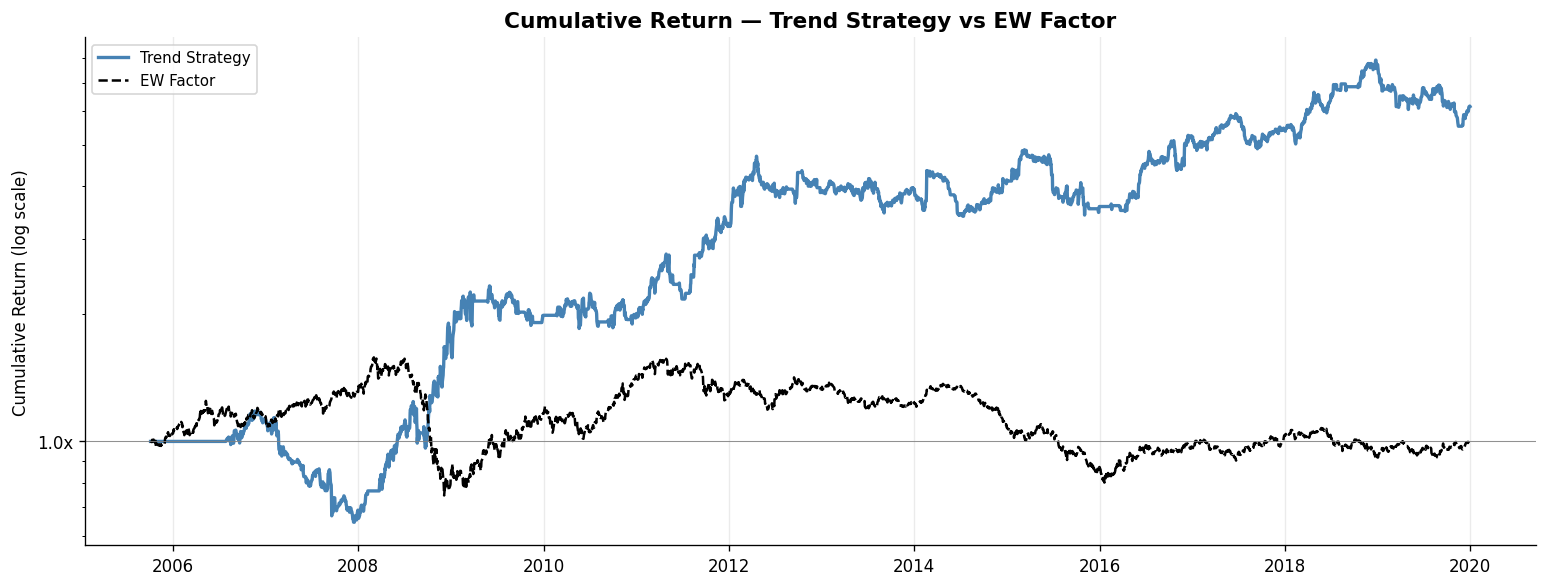

In [91]:
cum_strat  = (1 + port_r.dropna()).cumprod()
cum_factor = (1 + factor.reindex(port_r.index).dropna()).cumprod()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(cum_strat.index,  cum_strat.values,  color='steelblue', lw=2.0, label='Trend Strategy')
ax.plot(cum_factor.index, cum_factor.values, color='black',     lw=1.5, linestyle='--', label='EW Factor')
ax.axhline(1, color='grey', lw=0.5)
ax.set_yscale('log')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}x'))
ax.set_title('Cumulative Return — Trend Strategy vs EW Factor', fontsize=13, fontweight='bold')
ax.set_ylabel('Cumulative Return (log scale)')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
plt.show()

## 3. Sector Contribution

,Ann. Contribution %,Ann. Vol %,Sharpe
Agri & livestock,2.50,11.30,0.221
Energy,11.10,16.47,0.674
Metals,1.65,13.25,0.125


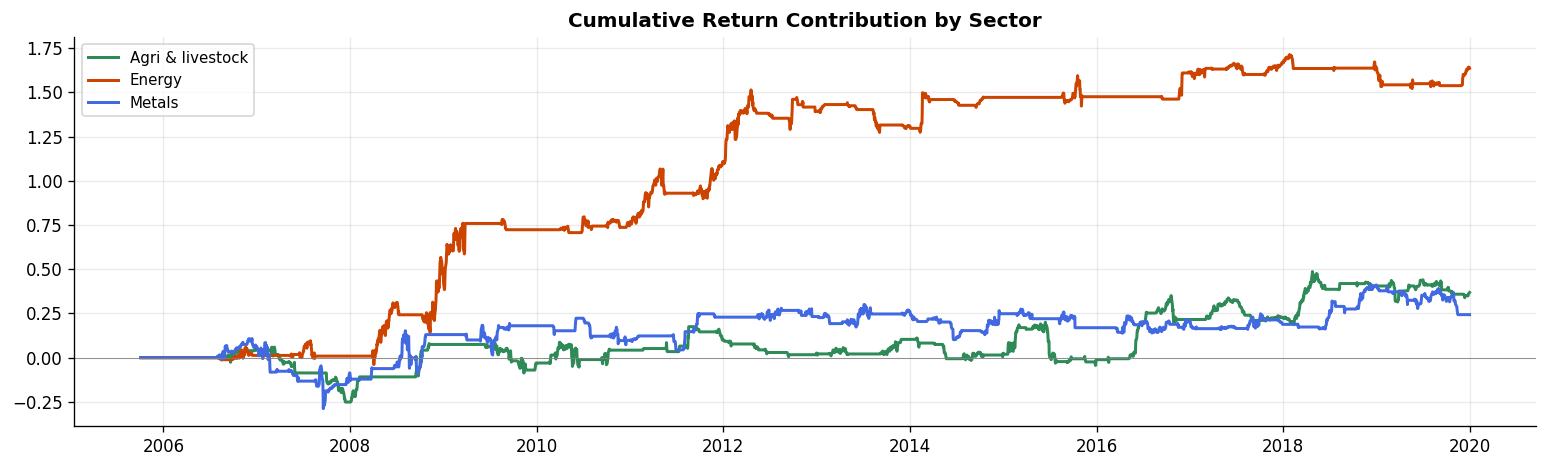

In [92]:
sc = sector_contribution(weights, returns, assets)

sc_summary = pd.DataFrame({
    'Ann. Contribution %' : (sc.mean() * 252 * 100).round(2),
    'Ann. Vol %'          : (sc.std()  * np.sqrt(252) * 100).round(2),
    'Sharpe'              : ((sc.mean() * 252) / (sc.std() * np.sqrt(252))).round(3),
})
display(sc_summary)

sector_colours = {'Agri & livestock': '#2e8b57', 'Energy': '#cc4400', 'Metals': '#4169e1'}
fig, ax = plt.subplots(figsize=(13, 4))
for col in sc.cumsum().columns:
    ax.plot(sc.cumsum().index, sc.cumsum()[col],
            color=sector_colours.get(col, 'grey'), lw=1.8, label=col)
ax.axhline(0, color='grey', lw=0.5)
ax.set_title('Cumulative Return Contribution by Sector', fontweight='bold')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
plt.show()

In [93]:
position_summary(positions)

,Days Long,Days Short,Days Flat,% Long,% Short
LIVE CATTLE,21,104,3590,0.6,2.8
LEAN HOGS,108,157,3450,2.9,4.2
COFFEE 'C',37,103,3575,1.0,2.8
CORN,44,246,3425,1.2,6.6
COTTON NO.2,96,42,3577,2.6,1.1
SOYBEAN,46,94,3575,1.2,2.5
SUGAR #11,41,199,3475,1.1,5.4
WHEAT FUTURE,60,180,3475,1.6,4.8
BRENT CRUDE,292,102,3321,7.9,2.7
COPPER FUTURE,87,136,3492,2.3,3.7


## 4. Signal Chart

Change `COMDTY` to inspect any commodity in the dataset.

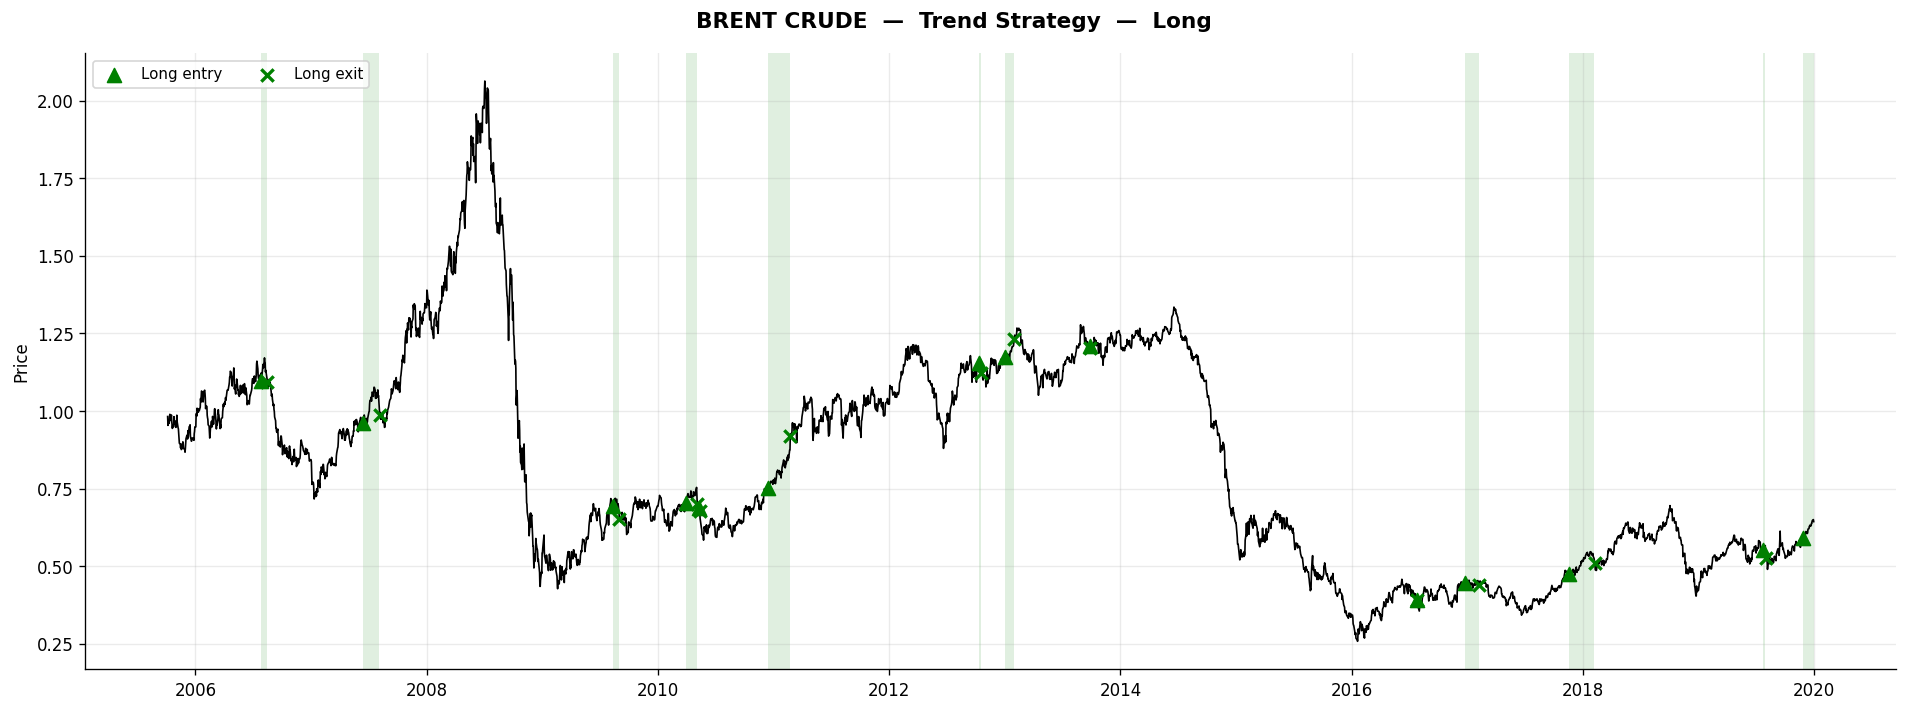

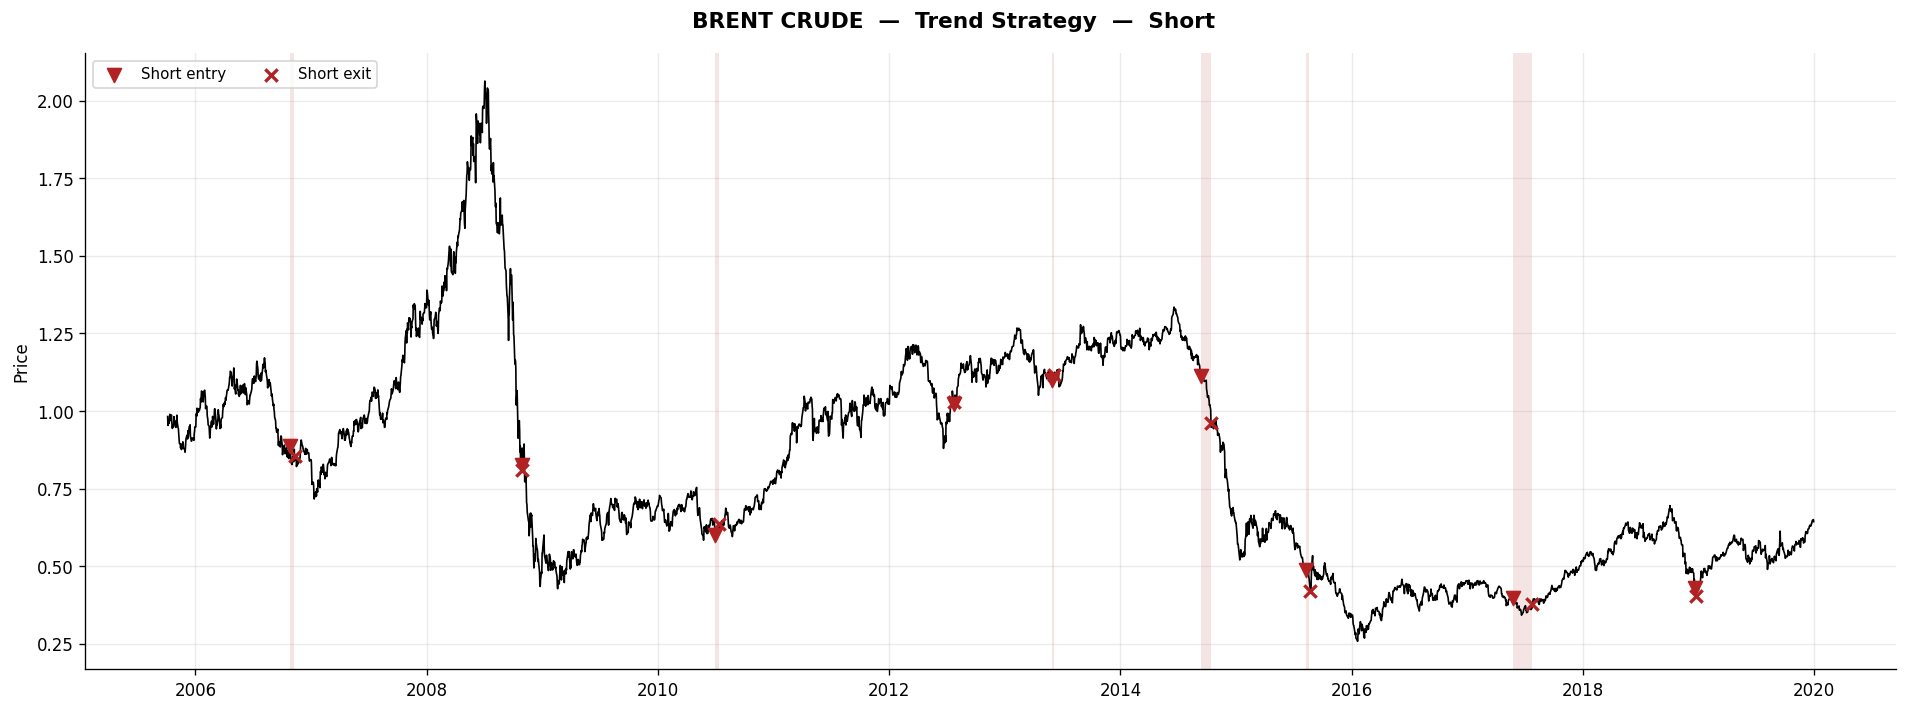

In [94]:
COMDTY = 'BRENT CRUDE'

plot_signals(prices, {'Trend Strategy': {
    'layer1_fn'    : layer1_fn,
    'exit_long_fn' : exit_long_fn,
    'exit_short_fn': exit_short_fn,
}}, COMDTY)

## 5. Save

In [95]:
OUT_DIR = '/Users/faisal/Desktop/backtesting/docs/task1_trend_outputs'
os.makedirs(OUT_DIR, exist_ok=True)

stats.to_csv(os.path.join(OUT_DIR, 'performance_summary.csv'))
sc_summary.to_csv(os.path.join(OUT_DIR, 'sector_contribution.csv'))
position_summary(positions).to_csv(os.path.join(OUT_DIR, 'position_activity.csv'))

print(f'Saved to {OUT_DIR}')

Saved to /Users/faisal/Desktop/backtesting/docs/task1_trend_outputs
